# <a id='toc1_'></a>[T23 State Space Control - Part 0](#toc0_)

**Table of contents**<a id='toc0_'></a>    
- [T23 State Space Control - Part 0](#toc1_)    
  - [State Space Control](#toc1_1_)    
  - [FSFB Place](#toc1_2_)    
    - [Compute the Bessel Pole Locations](#toc1_2_1_)    
    - [Example using Bessel Pole Locations](#toc1_2_2_)    
    - [ITAE Optimize](#toc1_2_3_)    
    - [ITAE step response](#toc1_2_4_)    

<!-- vscode-jupyter-toc-config
	numbering=false
	anchor=true
	flat=false
	minLevel=1
	maxLevel=6
	/vscode-jupyter-toc-config -->
<!-- THIS CELL WILL BE REPLACED ON TOC UPDATE. DO NOT WRITE YOUR TEXT IN THIS CELL -->

In [ ]:
# Course utilities (do not modify this cell)

from pathlib import Path
import sys

# repo_root/16_06_Class/notebooks → repo_root/16_06_Class
repo_root = Path.cwd().parents[0]
sys.path.insert(0, str(repo_root))

import courseutils.basic_material as bm
import courseutils.control_materials as cm

bm.setup_environment()
cm.setup_environment()

import numpy as np
import matplotlib.pyplot as plt
colors = bm.get_colors()

from scipy.optimize import fsolve


In [209]:
colors = bm.get_colors()
j = complex(0,1)
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.offsetbox import AnchoredText
import sympy as sp

import control as ct
import control.matlab as cmat

from scipy.optimize import minimize
from scipy.signal import butter,bessel

import warnings
warnings.filterwarnings(
    "ignore",
    message="divide by zero encountered in divide"
)
warnings.filterwarnings(
    "ignore",
    message="invalid value encountered in divide"
)

## <a id='toc1_1_'></a>[State Space Control](#toc0_)

Nbar =-15.00


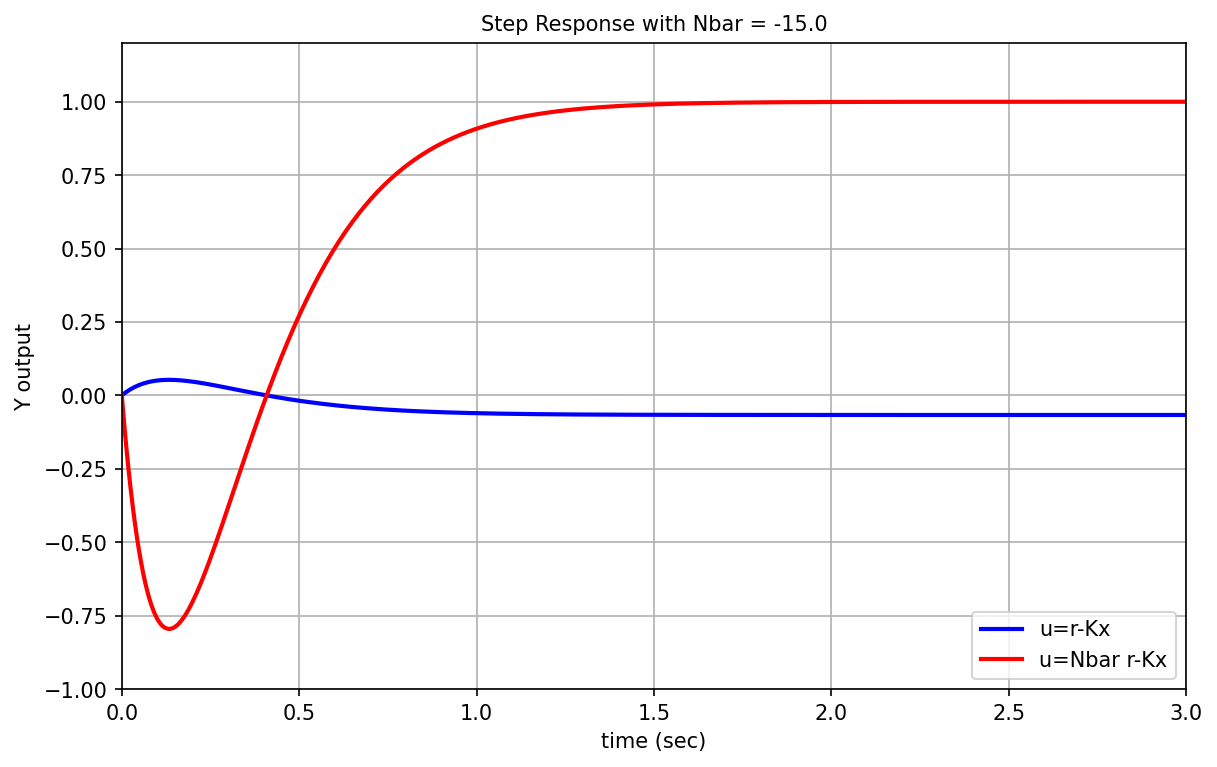

In [210]:
# full state feedback for topic 23
# reference input issues
#
a = np.array([[1, 1],[1, 2]])
nx = np.shape(a)[0]
b = np.array([1, 0]).reshape(nx,1)
c = np.array([1, 0])
d = 0

p = np.array([-5, -6])
# gains assumed found
k = ct.place(a, b, p)
acl = a-b*k

Nbar = 1/(-c@np.linalg.inv(acl)@b).item()
print(f"{Nbar =: 4.2f}")
sys1 = ct.ss(acl,b,c,d)
sys2 = ct.ss(acl,b*Nbar,c,d)

t = np.linspace(0,3,500)
y,t = cmat.step(sys1,t)
y2,t2 = cmat.step(sys2,t)

fig, ax = plt.subplots(1,figsize=(8, 5),dpi=150,constrained_layout = True)
plt.plot(t,y,'b-',label='u=r-Kx')
plt.plot(t2,y2,'r-',lw=2,label='u=Nbar r-Kx')
plt.axis([0, max(t), -1, 1.2])
plt.legend(loc=4)
plt.xlabel('time (sec)')
plt.ylabel('Y output')
plt.title('Step Response with'+f" {Nbar = : 3.1f}")
plt.savefig("figs/Nbar.pdf", dpi=600)
plt.show()

## <a id='toc1_2_'></a>[FSFB Place](#toc0_)

In [211]:
def compute_Nbar(G,k0):
    Nbar0 = 1.0/np.dot(-G.C,np.dot(np.linalg.inv(G.A-np.dot(G.B,k0)),G.B)).item()
    return Nbar0   

def FSFB_place(G,pr,file_name='temp',w=np.logspace(-1,2,400),Tmax=1):
    #
    k0 = ct.place(G.A,G.B,pr)
    # For state space for G_c(s) find the feedforward gains
    Nbar = compute_Nbar(G,k0)

    sys0 = ct.ss(G.A-G.B*k0,G.B,G.C,G.D)
    sys1 = ct.ss(G.A-G.B*k0,G.B*Nbar,G.C,G.D)

    Gf = G(w*j)
    sys0f = sys0(j*w)
    sys1f = sys1(j*w)
    ymax = max(np.max(np.abs(Gf)),np.max(np.abs(sys0f)),np.max(np.abs(sys1f)))
    ymax = 10**np.ceil(np.log10(1.5*ymax))

    t = np.arange(0,Tmax,.01)    
    y0,t0 = cmat.step(sys0,T=t)
    y1,t1 = cmat.step(sys1,T=t)

    fig, ax = plt.subplots(1,figsize=(8, 5),dpi=150,constrained_layout = True)
    ax.plot(t0,y0,'g-',label=r'$u=r-Kx$')
    ax.plot(t1,y1,'r-',label=r'$u=Nr-Kx$')
    plt.legend()
    yloc = (y0[len(t0)//2] + y1[len(t1)//2])/2.0
    plt.text(max(t0)/2,yloc,f"{Nbar = :3.1f}", fontsize=16)
    plt.ylabel("Response")
    plt.xlabel("Time")
    plt.savefig("figs/FSFB_pl"+file_name+"_0.pdf", dpi=600)
    plt.show()

    fig, ax = plt.subplots(2,1,figsize=(8, 5),dpi=150,constrained_layout = True)
    ax[0].loglog(w,np.abs(Gf),'b',label=r'G')
    ax[1].semilogx(w,np.unwrap(np.angle(Gf))*cm.r2d,'b',label=r'G')
    ax[0].loglog(w,np.abs(sys0f),'g',label=r'$u=r-Kx$')
    ax[1].semilogx(w,np.unwrap(np.angle(sys0f))*cm.r2d,'g',label=r'$u=r-Kx$')
    ax[0].loglog(w,np.abs(sys1f),'r',label=r'$u=Nr-Kx$')
    ax[1].semilogx(w,np.unwrap(np.angle(sys1f))*cm.r2d,'r',label=r'$u=Nr-Kx$')
    ax[1].set_xlabel('Freq [r/s]')
    ax[0].set_ylabel('Mag')
    ax[1].set_ylabel('Phase (degs)')
    ax[0].grid(True, which="both", ls="-",color='0.65')
    ax[1].grid(True, which="both", ls="-",color='0.65')
    ax[0].axhline(y=1,c='k',ls='--')
    ax[1].axhline(y=-180,c='k',ls='--')
    ax[0].legend()
    ax[0].set_ylim(1e-3,ymax)
    plt.savefig("figs/FSFB_pl"+file_name+"_1.pdf", dpi=600)
    plt.show()

    return k0

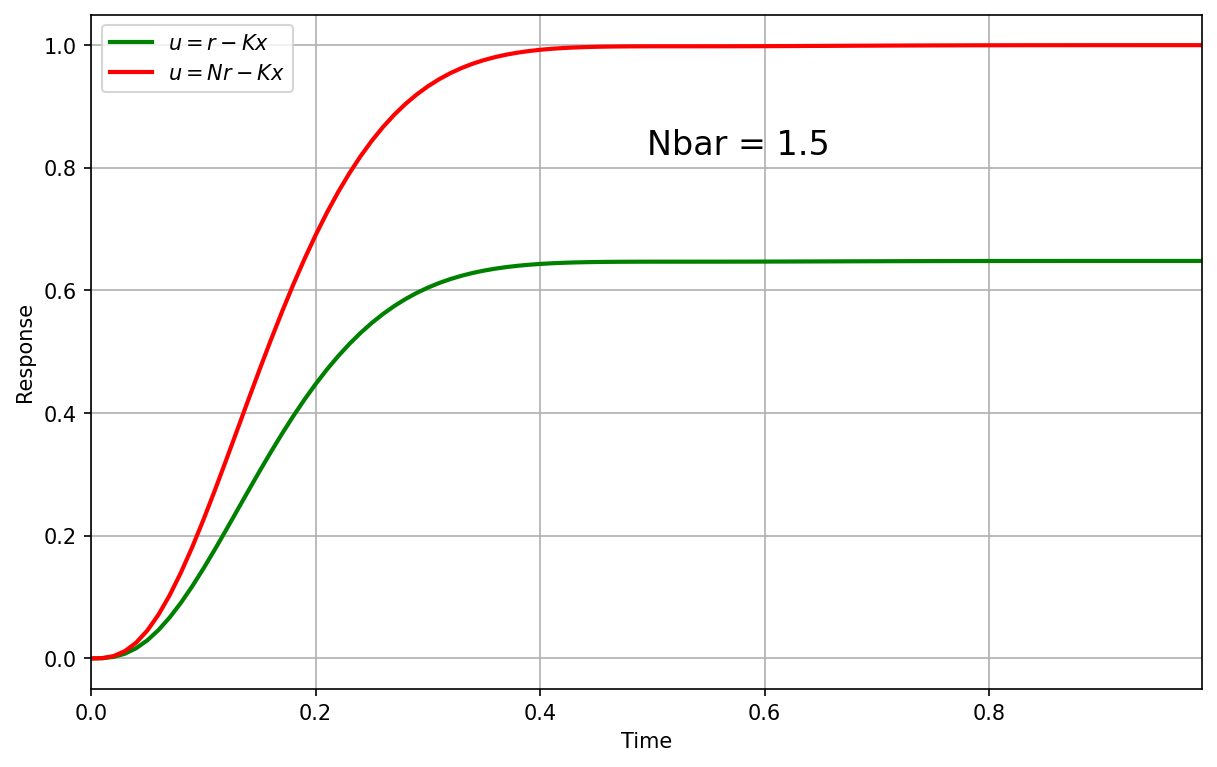

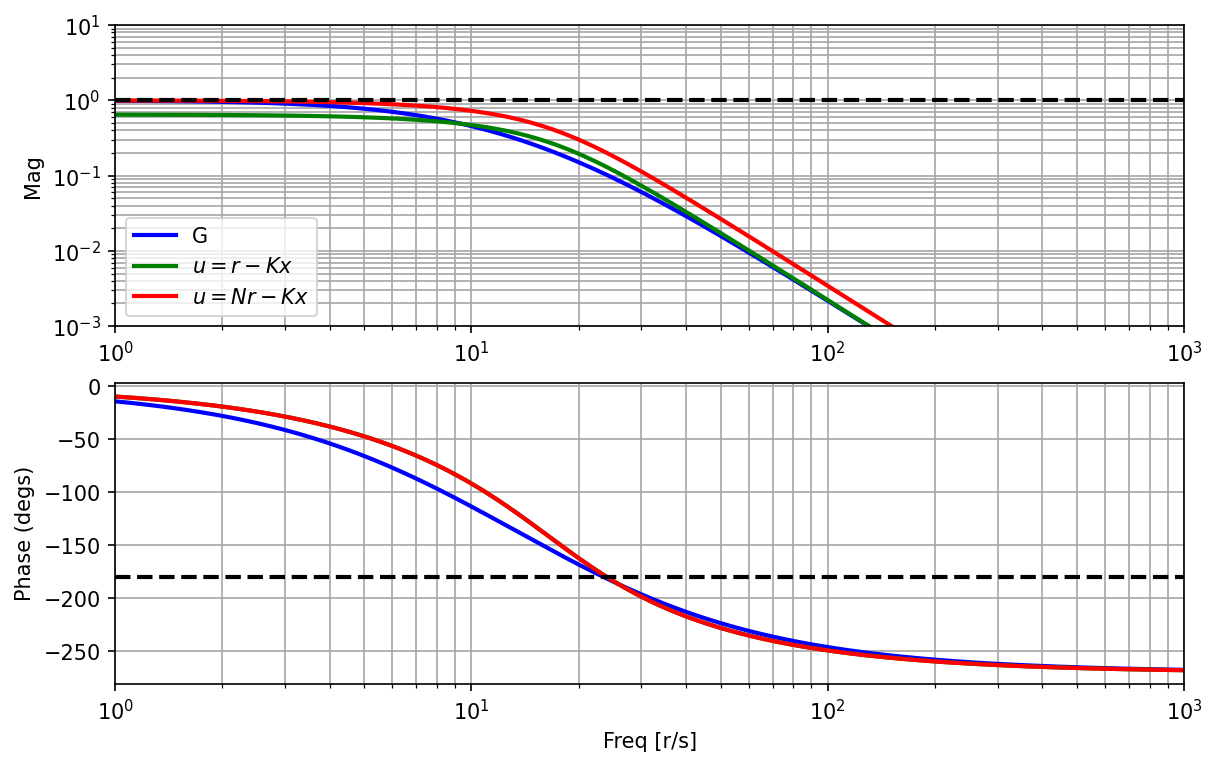

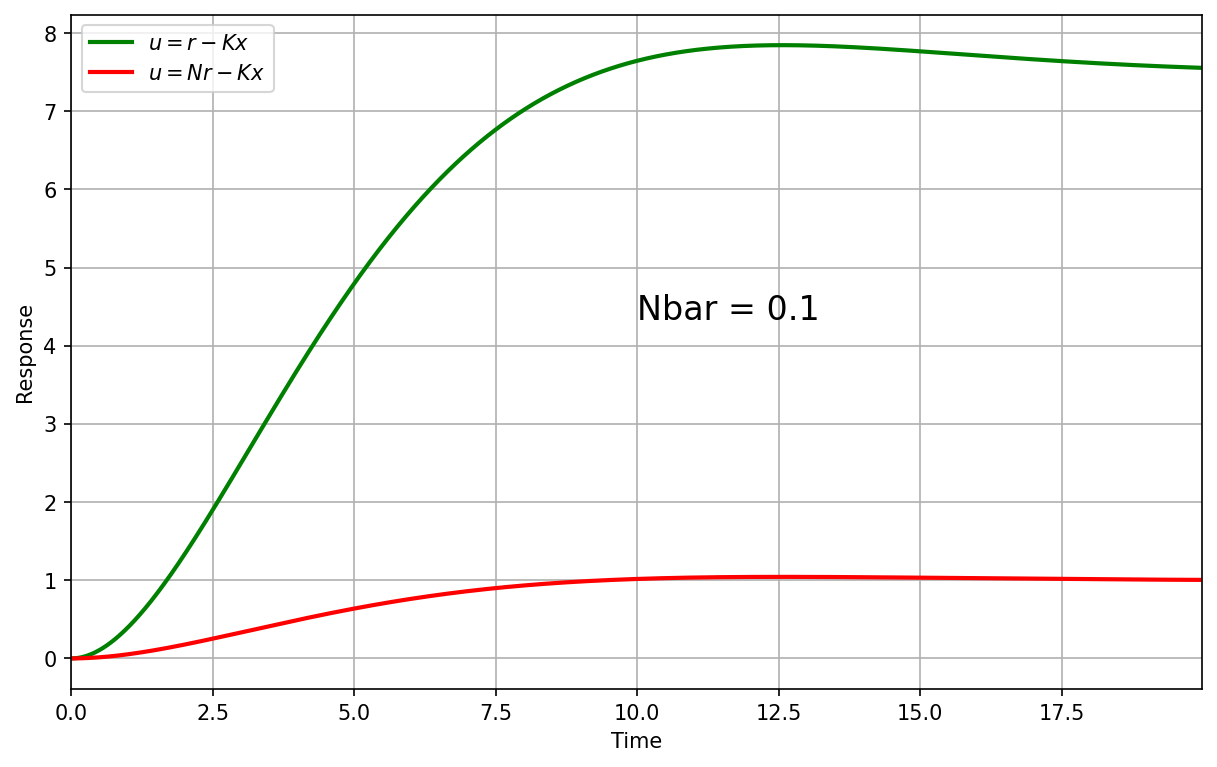

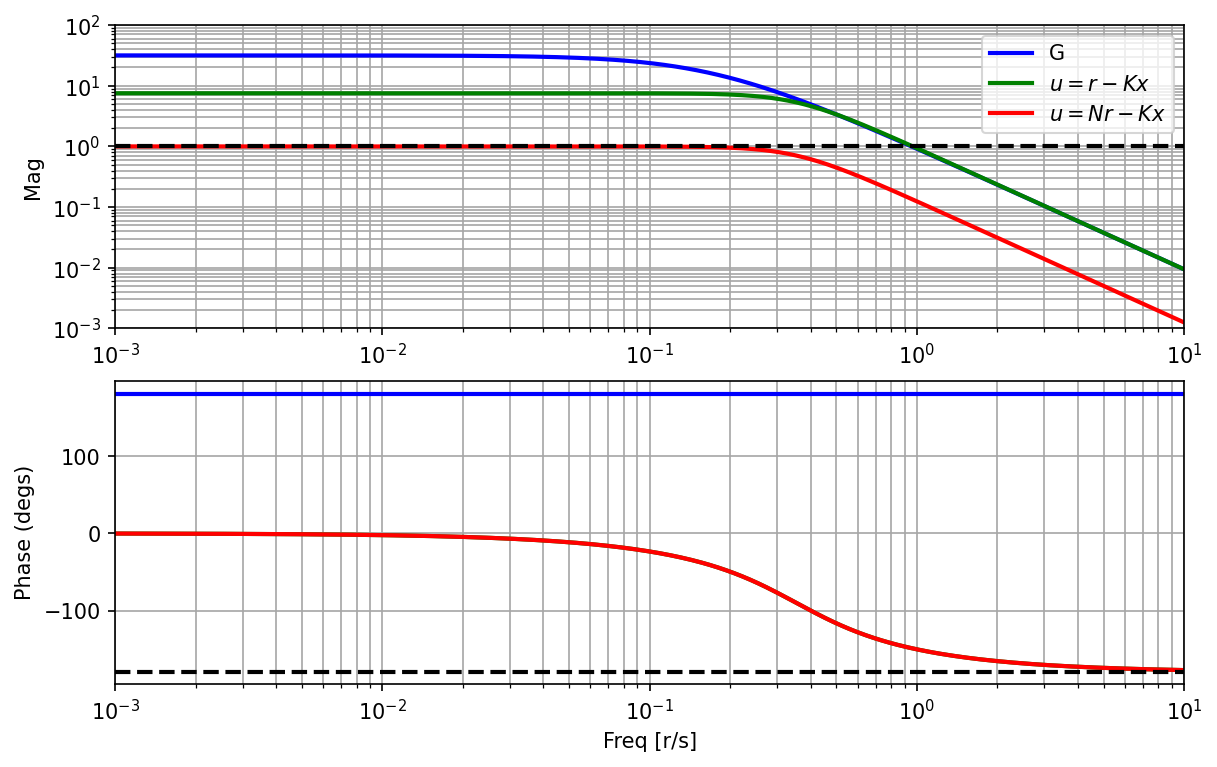

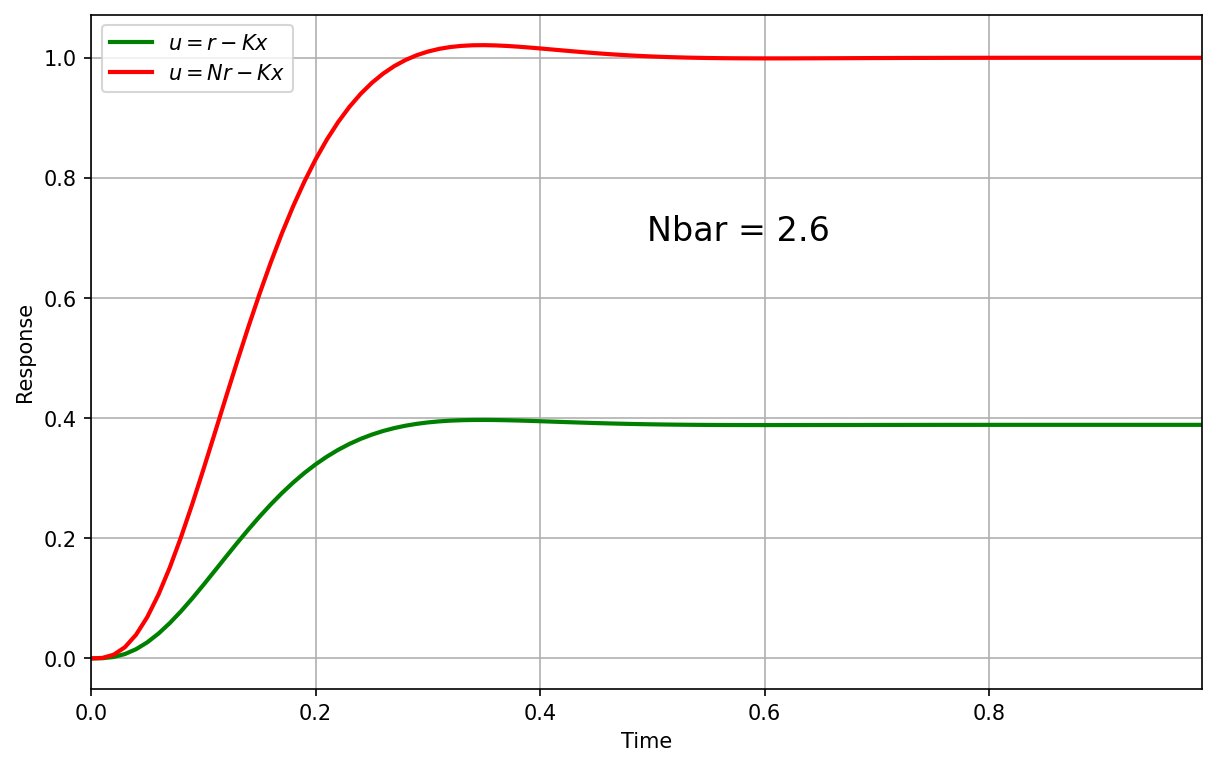

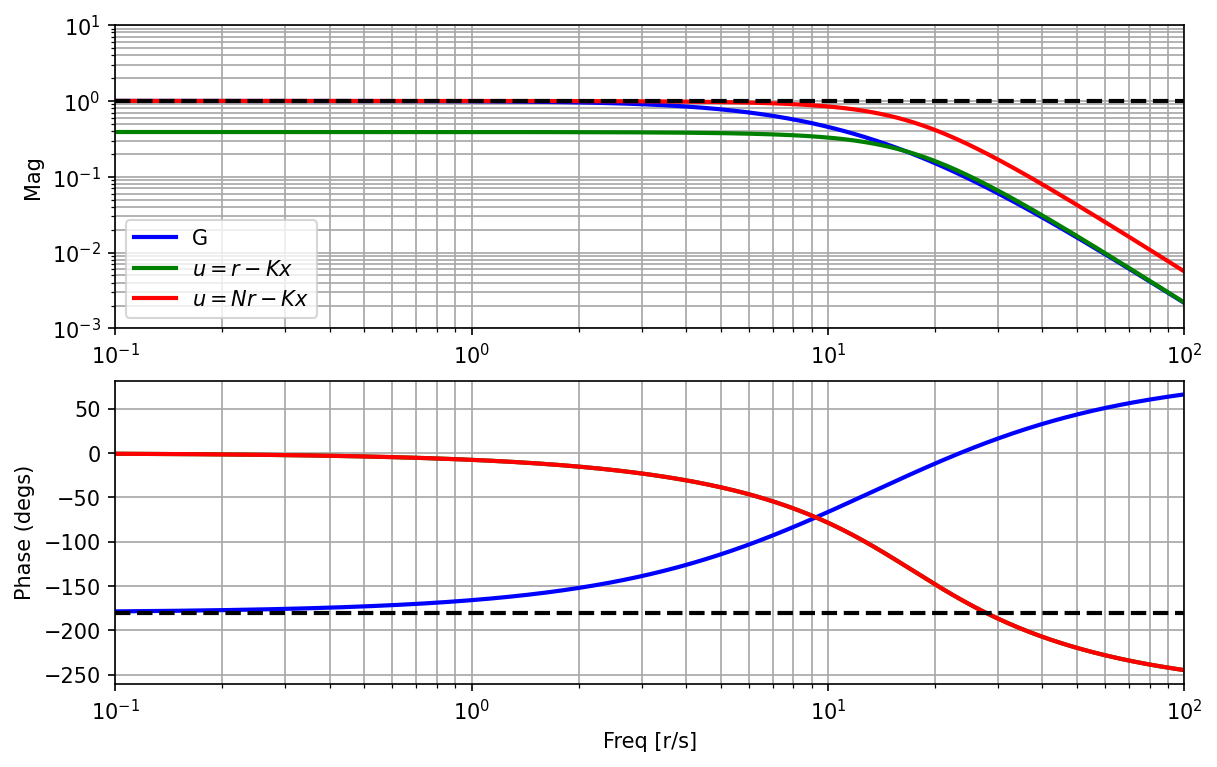

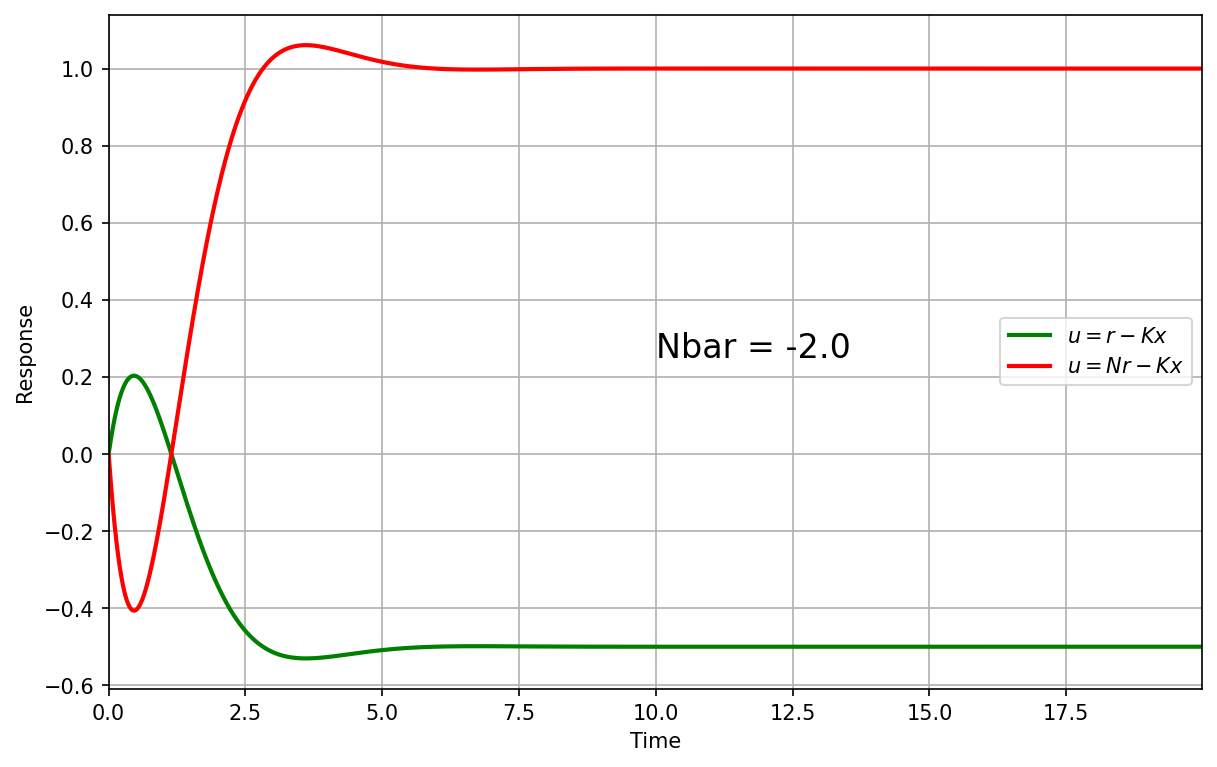

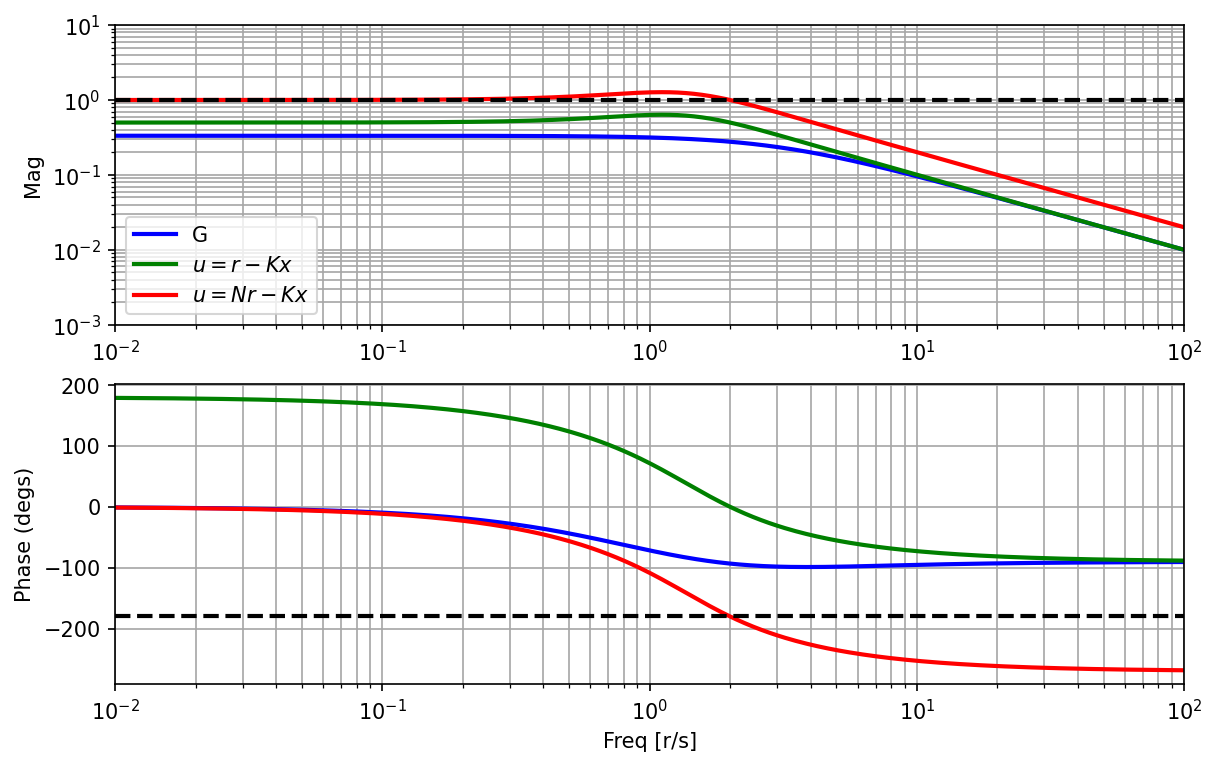

In [212]:
G1 = ct.ss(ct.tf(8*14*20,np.convolve([1, 8],np.convolve([1, 14],[1, 20]))))
pr = np.array([-12,-12+12*j,-12-12*j])
K1 = FSFB_place(G1,pr,file_name='examp1',w = np.logspace(0,3,400))

G2 = ct.ss(ct.tf(0.94,(1,0,-0.0297)))
pr = np.array([-0.25+0.25*j,-0.25-0.25*j])
K2 = FSFB_place(G2,pr,file_name='examp2',Tmax=20,w = np.logspace(-3,1,400))

G3 = ct.ss(ct.tf(8*14*20,np.convolve([1, -8],np.convolve([1, -14],[1, -20]))))
pr = np.array([-20,-12+12*j,-12-12*j])
K3 = FSFB_place(G3,pr,file_name='examp3', w = np.logspace(-1,2,400))

G4 = ct.ss(ct.tf((1,-1),(1,-2,-3)))
pr = np.array([-1+j,-1-j])
K4 = FSFB_place(G4,pr,file_name='examp4',Tmax=20,w = np.logspace(-2,2,400))


### <a id='toc1_2_1_'></a>[Compute the Bessel Pole Locations](#toc0_)

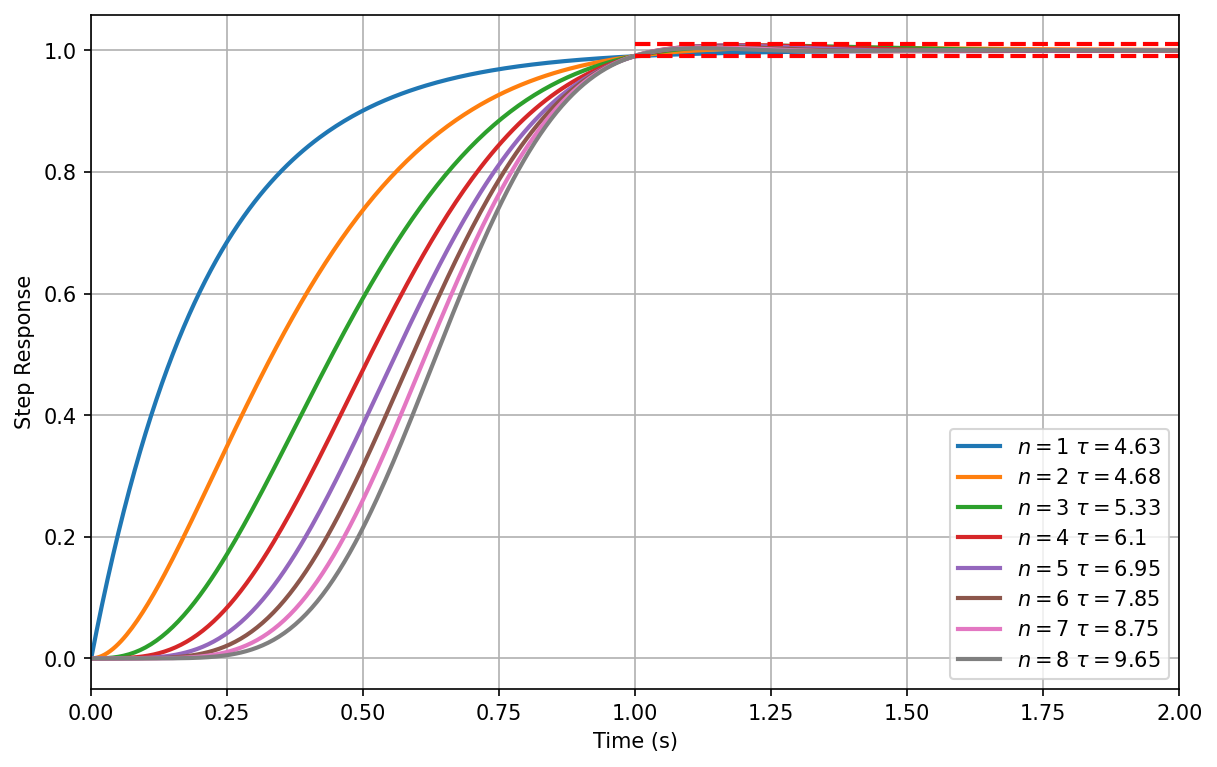

In [213]:
Bessel_poles={}

Npts = 2000
t_Bessel = np.linspace(0, 10, Npts)
Tol = 0.01

def func(tau,t,a,b,Tol=0.01,y_ss=1.0,ts_targ=1):
    tau = float(tau[0])
    if tau <= 0:
        return 1e6

    n = len(a) - 1
    AA = [xx/tau**(n - kk) for kk, xx in enumerate(a)]
    y,_ = cmat.step(ct.tf(b,AA),T=t)

    # Find the index where y is within 2% of the final value
    err = np.abs(y - y_ss)
    viol = err >= Tol
    if np.any(viol):
        t_settle = t[np.where(viol)[0][-1] + 1]
    else:
        t_settle = 0.0
    return (t_settle - ts_targ)**2

fig, ax = plt.subplots(1,figsize=(8, 5),dpi=150,constrained_layout = True)
for n in range(1,9):
    b, a = bessel(n, 1, analog=True)
    sol = minimize(func, x0 = 1,method='Nelder-Mead',args=(t_Bessel,a,b),tol=1e-4)
 
    tau = sol.x[0]  # Extract the scalar value from the array
    A = [xx / tau**(n - kk) for kk, xx in enumerate(a)]
 
    y_Bessel,_ = cmat.step(ct.tf(b, A), T=t_Bessel)
    plt.plot(t_Bessel, y_Bessel,label=r'$n = $'+str(n)+r' $\tau=$'+str(np.round(tau,2)))
    Bessel_poles[n] = np.roots(A)
    cm.pretty_row_print(np.roots(A),"n = "+str(n)+": ")

plt.legend()
plt.axhline(y=(1+Tol),ls='--',xmin=1/2,c='r')
plt.axhline(y=(1-Tol),ls='--',xmin=1/2,c='r')
plt.xlim(0,2)
plt.ylabel('Step Response')
plt.xlabel('Time (s)')
plt.savefig("figs/Bessel_step_response.pdf", dpi=600)
plt.show()

In [214]:
def format_poles_latex(poles, tol=1e-6, ndigits=2):
    poles = list(poles)
    used = np.zeros(len(poles), dtype=bool)
    entries = []

    for i, p in enumerate(poles):

        if used[i]:
            continue

        if abs(p.imag) < tol:
            entries.append(f"${p.real:.{ndigits}f}$")
            used[i] = True
        else:
            # find conjugate
            for j in range(i + 1, len(poles)):
                if used[j]:
                    continue
                if abs(poles[j] - np.conj(p)) < tol:
                    a = p.real
                    b = abs(p.imag)
                    entries.append(
                        f"${a:.{ndigits}f} \\pm {b:.{ndigits}f}i$"
                    )
                    used[i] = True
                    used[j] = True
                    break

    return ", ".join(entries)

print(r"\begin{tabular}{l}")
print(r"\hline")
print(r"Poles for a 1\% settling time \\")
print(r"\hline")

for n in sorted(Bessel_poles.keys()):
    pole_str = format_poles_latex(Bessel_poles[n])
    print(f"${n}$ & {pole_str} \\\\")

print(r"\hline")
print(r"\end{tabular}")



\begin{tabular}{l}
\hline
Poles for a 1\% settling time \\
\hline
$1$ & $-4.63$ \\
$2$ & $-4.05 \pm 2.34i$ \\
$3$ & $-3.97 \pm 3.79i$, $-5.01$ \\
$4$ & $-4.01 \pm 5.06i$, $-5.52 \pm 1.65i$ \\
$5$ & $-4.10 \pm 6.31i$, $-6.44$, $-5.92 \pm 3.08i$ \\
$6$ & $-4.23 \pm 7.55i$, $-6.28 \pm 4.41i$, $-7.14 \pm 1.46i$ \\
$7$ & $-4.35 \pm 8.77i$, $-6.59 \pm 5.69i$, $-8.05$, $-7.70 \pm 2.81i$ \\
$8$ & $-4.46 \pm 9.98i$, $-6.86 \pm 6.93i$, $-8.18 \pm 4.11i$, $-8.78 \pm 1.36i$ \\
\hline
\end{tabular}


### <a id='toc1_2_2_'></a>[Example using Bessel Pole Locations](#toc0_)

n = 3


[-1.98526753+1.89401364j -1.98526753-1.89401364j -2.50701007+0.j        ]


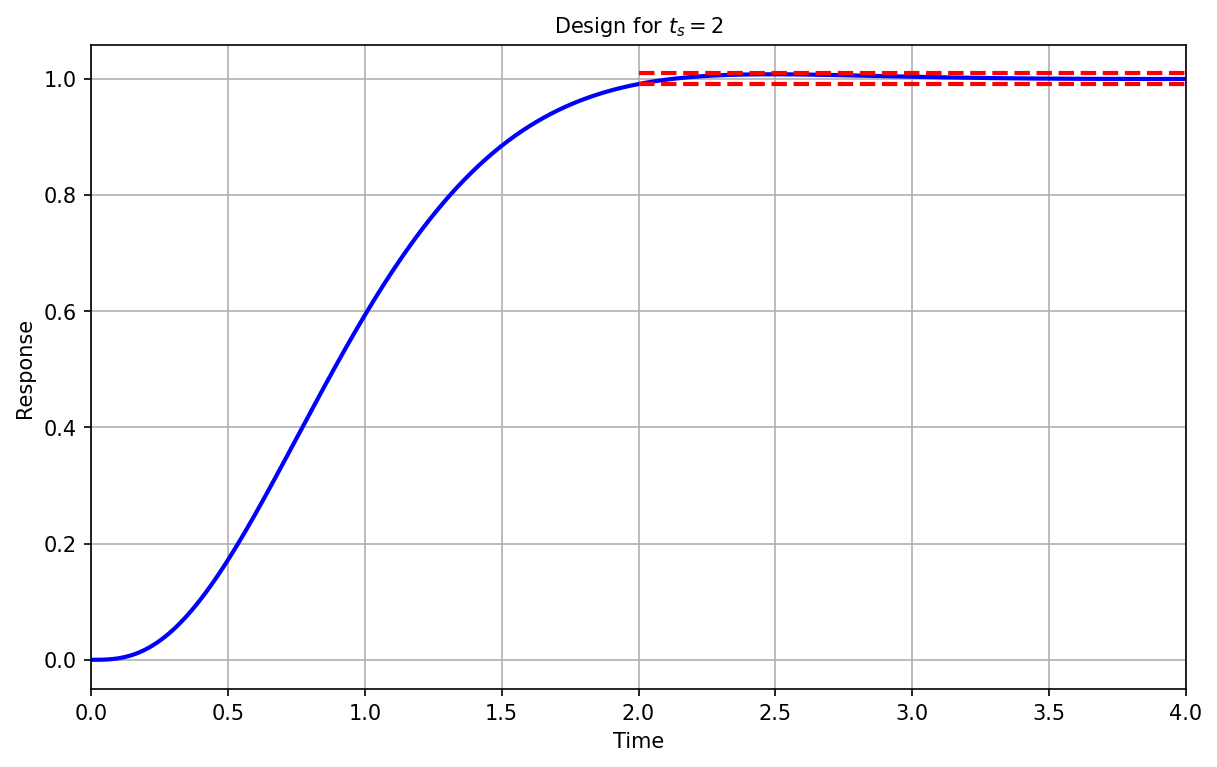

In [215]:
# system
G = ct.tf(1,[1 ,0]) * ct.tf(1,[1 ,4]) * ct.tf(1,[1 ,1])
n = len(G.den[0][0]) - 1
print(f"{n =: 2d}")
Gss = ct.tf2ss(G)
tau = 2 # scaling factor on time constant
Tf = 2 * tau
#get p from above cell
if 0:
    p = (complex(-3.95,3.77), complex(-3.95, -3.77), complex(-4.99 , 0.00))
else:
    p = Bessel_poles[n]
cm.pretty_row_print(p)
p_scaled = [pp/tau for pp in p]
cm.pretty_row_print(p_scaled)

K = ct.place(Gss.A,Gss.B,p_scaled)
Acl = Gss.A-Gss.B @ K
print(np.linalg.eig(Acl)[0])
Nbar = compute_Nbar(Gss,K)
Gcl = Nbar*ct.ss(Acl,Gss.B,Gss.C,Gss.D)

t_Bessel = np.linspace(0,Tf,Npts)
y_Bessel,t_Bessel = cmat.step(Gcl,T=t_Bessel)

fig, ax = plt.subplots(1,figsize=(8, 5),dpi=150,constrained_layout = True)
plt.plot(t_Bessel,y_Bessel,'b')
plt.axhline(y=(1+Tol),ls='--',xmin=tau/Tf,c='r')
plt.axhline(y=(1-Tol),ls='--',xmin=tau/Tf,c='r')
plt.ylabel("Response")
plt.xlabel("Time")
plt.title('Design for $t_s=$'+str(tau))
plt.savefig("figs/Bessel_1.pdf", dpi=600)
plt.show()

### <a id='toc1_2_3_'></a>[ITAE Optimize](#toc0_)

In [216]:
from scipy.signal import residue
import scipy.integrate
from scipy.linalg import expm

Npts = 2000
Tf = 20
t_ITAE = np.linspace(0, Tf, Npts)
ts_targ = 1.0

def func(a,t):
    A = [1] + list(np.flip(a)) + [1]
    y,_ = cmat.step(ct.tf(1, A), T = t)
    abs_error = np.abs(1 - y)
    ITAE = scipy.integrate.trapezoid(t * abs_error,t)
    return ITAE

# https://web.cecs.pdx.edu/~tymerski/ece451/The%20Optimal%20ITAE%20Transfer%20Functions%20for%20Step%20Input.pdf
# these are the original ITAE coefficients
itaeOrg = {
    2: [1.505],                                 # 1.000    1.505    1.000  
    3: [1.783, 2.172],                          # 1.000    1.783    2.172    1.000   
    4: [1.953,    3.347,    2.648],             # 1.000    1.953    3.347    2.648    1.000  
    5: [2.068,    4.499,    4.675,    3.257],
    6: [3.25, 6.60, 8.60, 7.45, 3.95],
    7: [4.475, 10.42, 15.08, 15.54, 10.64, 4.58],
    8: [5.2, 12.8, 21.6, 25.75, 22.2, 13.3, 5.15]
}


In [217]:

def my_pfe(A,t) :
    A = np.convolve(A, [1, 0])  # Multiply by s to get the correct order
    rr, pp, _ = scipy.signal.residue([1], A)
    # Compute the time response of each term
    time_responses = []
    for residue, pole in zip(rr, pp):
        response = residue * np.exp(pole * t)
        time_responses.append(response)

    # Combine the responses to get the total response
    total_response = np.sum(time_responses, axis=0)
    return total_response


In [218]:
def itaecost(p,t_ITAE,return_traj=False):
    X = []
    nn = len(p)
    dt = t_ITAE[1] - t_ITAE[0]
    # form state space system
    A = np.zeros((nn + 1, nn + 1))
    A[:-1,1:] = np.eye(nn)
    A[-1, :] = -np.array([1] + list(p))   
    #pp = [1]+list(np.flip(p))+[1]

    # discretize the system
    B = np.zeros((nn + 1, 1))
    B[-1] = 1
    AB = np.block([[A, B], [np.zeros((1, nn + 2))]])
    exp_AB = expm(AB * dt)

    x = np.zeros((nn + 2, 1))
    x[-1] = 1
    for tt in t_ITAE:
        X = np.append(X,x[0,0])
        x = exp_AB @ x.reshape(nn+2, 1)
    
    E = scipy.integrate.trapezoid(t_ITAE * np.abs(1 - np.array(X)), t_ITAE)
    
    if return_traj:
        return E, np.array(X)
    return E


In [ ]:
fig, ax = plt.subplots(1,figsize=(8, 5),dpi=150,constrained_layout = True)
ITAE_poles = {}
ITAE_scaled_poles = {}
check_old = False
plot_scaled = True
Tol = 0.01

def time_scale_poly(A, tau):
    n = len(A) - 1
    return [xx / tau**(n - k) for k, xx in enumerate(A)]

for n in range(1,9): 
    print(f"\n {n =: 2d}")
    if n > 1:
        # choose starting guess from itaeOrg (keys are integers)
        x0 = np.array(itaeOrg[n])
            
        if check_old:
            sol = minimize(itaecost, x0=x0, args=(t_ITAE), method='Nelder-Mead', tol=1e-9)
        else:
            sol = minimize(func, x0=x0, args=(t_ITAE), method='Nelder-Mead', tol=1e-9)

        A = [1]+list(np.flip(sol.x))+[1]
    else:
        A = [1, 1]

    ITAE_poles[n] = np.roots(A) 
    cm.pretty_row_print(A,"Coeffs: ")
        
    y_ITAE,_ = cmat.step(ct.tf(1, A), T=t_ITAE)
    abs_error = np.abs(1.0 - y_ITAE)
    ITAE_mine = scipy.integrate.trapezoid(t_ITAE * abs_error,t_ITAE)
    print(f"{ITAE_mine = :.3f}")

    if check_old:
        ITAE, X = itaecost(sol.x,t_ITAE, return_traj=True)
        print(f"Old {ITAE = :.3f}")

    viol = np.abs(y_ITAE - 1.0) >= Tol
    if np.any(viol):
        tau = float(t_ITAE[np.where(viol)[0][-1]])
    else:
        tau = 1.0

    # time scaling
    AA = time_scale_poly(A, tau)
    ITAE_scaled_poles[n] = np.roots(AA)

    y_scaled_ITAE,_ = cmat.step(ct.tf(1, AA), T=t_ITAE)
    abs_scaled_error = np.abs(1.0 - y_scaled_ITAE)
    ITAE_scaled_mine = scipy.integrate.trapezoid(t_ITAE * abs_scaled_error,t_ITAE)

    cm.pretty_row_print(ITAE_poles[n],"Poles: ")
    cm.pretty_row_print(ITAE_scaled_poles[n],"Scaled Poles: ")

    if plot_scaled:
        plt.plot(t_ITAE,y_scaled_ITAE,label=r'$n = $'+str(n)+r' ITAE = '+str(np.round(ITAE_scaled_mine,3)),c=colors[n-1],lw=2)
    else:
        plt.plot(t_ITAE, y_ITAE,label=r'$n = $'+str(n),c=colors[n],lw=2)

if check_old:
    plt.plot(t_ITAE,X,'k--',label='Old ITAE = '+str(np.round(ITAE,3)),lw=2)
    plt.plot(t_ITAE, 1e12*(X - y_ITAE),label='1e12 Old Error')

if plot_scaled:
    Pred_resp = my_pfe(AA,t_ITAE)
    Err2 = np.abs(Pred_resp - y_scaled_ITAE)
else:
    Pred_resp = my_pfe(A,t_ITAE)
    Err2 = np.abs(Pred_resp - y_ITAE)

if 0:
    plt.plot(t_ITAE,Pred_resp,'c--',label='Analytic ITAE',lw=3)
    plt.plot(t_ITAE, 1e12*Err2,label='1e12 Error2')

plt.axhline(y=1.02,ls='--',xmin=1/2,c='r')
plt.axhline(y=1/1.02,ls='--',xmin=1/2,c='r')
if plot_scaled:
    plt.xlim(0,2)
else:
    plt.xlim(0,Tf)

plt.ylim(-0.1,1.2)
plt.ylabel('Step Response')
plt.xlabel('Time (s)')
plt.title("ITAE Optimized")
plt.legend()
plt.savefig("figs/ITAE_step_response.pdf", dpi=600)
plt.show()


 n = 1


ITAE_mine = 1.000



 n = 2


ITAE_mine = 1.952



 n = 3


ITAE_mine = 3.138



 n = 4


ITAE_mine = 4.586



 n = 5


In [ ]:
print(r"\begin{tabular}{c l}")
print(r"\hline")
print(r"$n$ & Poles for 1\% settling time \\")
print(r"\hline")

for n in sorted(ITAE_scaled_poles.keys()):
    if n == 1:
        pole_str = f"${ITAE_scaled_poles[n].item():.2f}$"
    else:
        pole_str = format_poles_latex(ITAE_scaled_poles[n])

    print(f"${n}$ & {pole_str} \\\\")

print(r"\hline")
print(r"\end{tabular}")

\begin{tabular}{c l}
\hline
$n$ & Poles for 1\% settling time \\
\hline
$1$ & $-4.60$ \\
$2$ & $-4.96 \pm 4.33i$ \\
$3$ & $-4.46 \pm 8.82i$, $-5.90$ \\
$4$ & $-3.88 \pm 13.35i$, $-5.87 \pm 4.27i$ \\
$5$ & $-3.31 \pm 17.83i$, $-5.41 \pm 8.70i$, $-6.56$ \\
$6$ & $-2.62 \pm 22.42i$, $-4.73 \pm 13.28i$, $-6.46 \pm 4.24i$ \\
$7$ & $-1.93 \pm 26.92i$, $-4.10 \pm 17.86i$, $-5.99 \pm 8.67i$, $-6.99$ \\
$8$ & $-2.81 \pm 27.93i$, $-3.73 \pm 21.97i$, $-5.02 \pm 13.22i$, $-6.43 \pm 4.39i$ \\
\hline
\end{tabular}


### <a id='toc1_2_4_'></a>[ITAE step response](#toc0_)

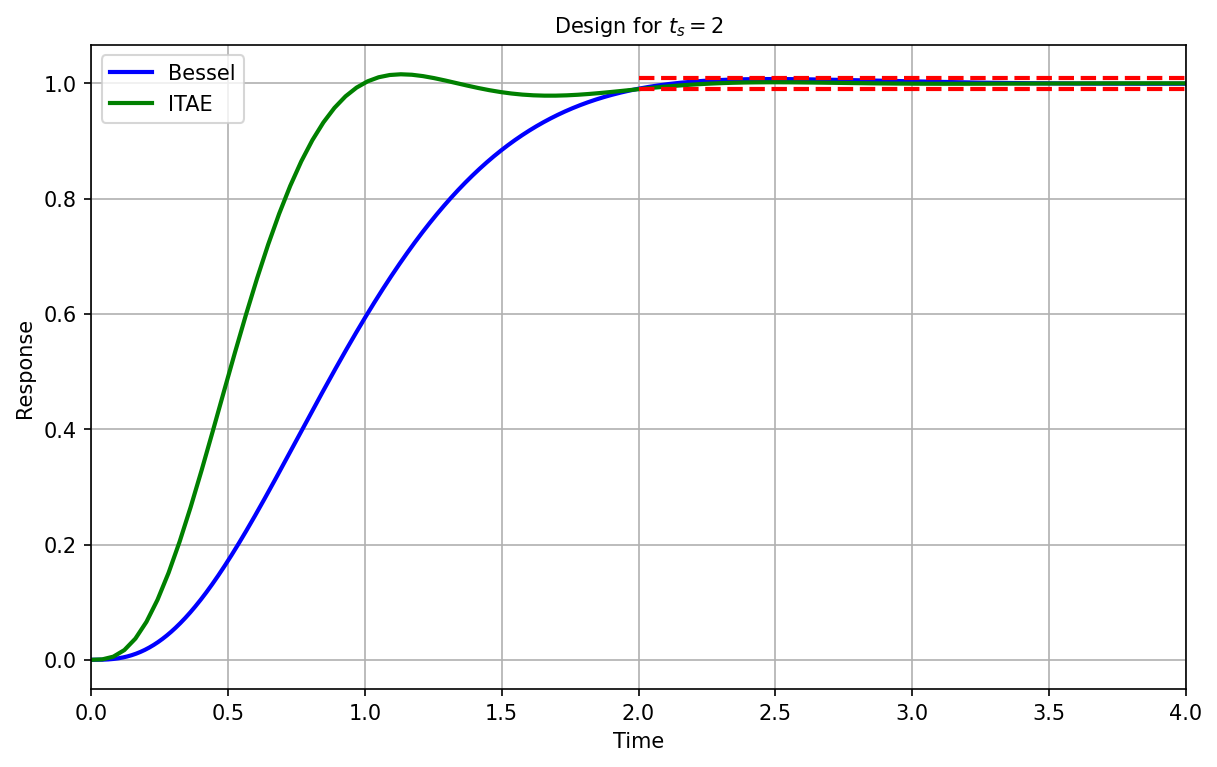

In [ ]:
Tol = 0.01
tau = 2
n = 3
Tf = 2*tau

p = ITAE_scaled_poles[n]
cm.pretty_row_print(p, "ITAE poles")
p_scaled = [pp/tau for pp in p]
cm.pretty_row_print(p_scaled, "Scaled poles")

K = ct.place(Gss.A,Gss.B,p_scaled)
Acl = Gss.A-Gss.B @ K
cm.pretty_row_print(np.linalg.eig(Acl)[0],"Eigenvalues ")
Nbar = compute_Nbar(Gss,K)
Gcl = Nbar*ct.ss(Acl,Gss.B,Gss.C,Gss.D)

y_ITAE,tt = cmat.step(Gcl,T=Tf)

fig, ax = plt.subplots(1,figsize=(8, 5),dpi=150,constrained_layout = True)
plt.plot(t_Bessel,y_Bessel,'b',label='Bessel')
plt.plot(tt,y_ITAE,'g',label='ITAE')
plt.axhline(y=y_ITAE[-1]*(1+Tol),ls='--',xmin=tau/max(tt),c='r')
plt.axhline(y=y_ITAE[-1]*(1-Tol),ls='--',xmin=tau/max(tt),c='r')
plt.ylabel("Response")
plt.xlabel("Time")
plt.xlim(0,2*tau)
plt.legend()
plt.title('Design for $t_s=$'+str(tau))
plt.savefig("figs/Bessel_2.pdf", dpi=600)
plt.show()


In [ ]:
# Save Bessel_poles and ITAE_scaled_poles to pole_locations.py
with open("pole_locations.py", "w") as f:
    f.write("# This file contains pole location data\n\n")
    f.write("import numpy as np\n\n")
    f.write("from control_materials import *\n\n")

    f.write("Bessel_poles = {\n")
    for key, value in Bessel_poles.items():
        f.write(f"    {key}: {list(value)},\n")
    f.write("}\n\n")
    
    f.write("ITAE_scaled_poles = {\n")
    for key, value in ITAE_scaled_poles.items():
        f.write(f"    {key}: {list(value)},\n")
    f.write("}\n")

    f.write("if __name__ == '__main__':\n")
    f.write("    print('Bessel_poles:', Bessel_poles)\n")
    f.write("    print('ITAE_scaled_poles:', ITAE_scaled_poles)\n")
    

In [ ]:
from pole_locations import *
print("\nBessel poles")

for key, value in Bessel_poles.items():
    pretty_row_print(value,str(key)+": ")

print("\nITAE poles")
    
for key, value in ITAE_scaled_poles.items():
    pretty_row_print(value,str(key)+": ")


Bessel poles
1: -4.625
2: (-4.05 + 2.34i), (-4.05 + -2.34i)
3: (-3.97 + 3.79i), (-3.97 + -3.79i), -5.014
4: (-4.01 + 5.06i), (-4.01 + -5.06i), (-5.52 + 1.65i), (-5.52 + -1.65i)
5: (-4.10 + 6.31i), (-4.10 + -6.31i), -6.439, (-5.92 + 3.08i), (-5.92 + -3.08i)
6: (-4.23 + 7.55i), (-4.23 + -7.55i), (-6.28 + 4.41i), (-6.28 + -4.41i), (-7.14 + 1.46i), (-7.14 + -1.46i)
7: (-4.35 + 8.77i), (-4.35 + -8.77i), (-6.59 + 5.69i), (-6.59 + -5.69i), -8.046, (-7.70 + 2.81i), (-7.70 + -2.81i)
8: (-4.46 + 9.98i), (-4.46 + -9.98i), (-6.86 + 6.93i), (-6.86 + -6.93i), (-8.18 + 4.11i), (-8.18 + -4.11i), (-8.78 + 1.36i), (-8.78 + -1.36i)

ITAE poles
1: -4.602
2: (-4.96 + 4.33i), (-4.96 + -4.33i)
3: (-4.46 + 8.82i), (-4.46 + -8.82i), -5.901
4: (-3.88 + 13.35i), (-3.88 + -13.35i), (-5.87 + 4.27i), (-5.87 + -4.27i)
5: (-3.31 + 17.83i), (-3.31 + -17.83i), (-5.41 + 8.70i), (-5.41 + -8.70i), -6.562
6: (-2.62 + 22.42i), (-2.62 + -22.42i), (-4.73 + 13.28i), (-4.73 + -13.28i), (-6.46 + 4.24i), (-6.46 + -4.24i)
7: (-1.